In [89]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
spambase = fetch_ucirepo(id=94) 
  
# data (as pandas dataframes) 
X = spambase.data.features 
y = spambase.data.targets 
  
# metadata 
print(spambase.metadata) 
  
# variable information 
print(spambase.variables) 


{'uci_id': 94, 'name': 'Spambase', 'repository_url': 'https://archive.ics.uci.edu/dataset/94/spambase', 'data_url': 'https://archive.ics.uci.edu/static/public/94/data.csv', 'abstract': 'Classifying Email as Spam or Non-Spam', 'area': 'Computer Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 4601, 'num_features': 57, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1999, 'last_updated': 'Mon Aug 28 2023', 'dataset_doi': '10.24432/C53G6X', 'creators': ['Mark Hopkins', 'Erik Reeber', 'George Forman', 'Jaap Suermondt'], 'intro_paper': None, 'additional_info': {'summary': 'The "spam" concept is diverse: advertisements for products/web sites, make money fast schemes, chain letters, pornography...\n\nThe classification task for this dataset is to determine whether a given email is spam or not.\n\t\nOur collecti

In this problem, you will use existing packages of your choice for training and testing various classifiers, and then compare them. You
will use the same *SPAMBASE* dataset. You can use the same training and testing data as in Problem 1. Train the following classifiers using the training data:

- Logistic regression
- LDA
- kNN

In [90]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np



In [91]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

Use cross-validation to select the $k$ hyper-parameter for kNN. Show the accuracy, error, precision, and recall metrics on the validation dataset for multiple values of $k$. Select the value of $k$ that minimizes the average cross validation error.

In [92]:
sqrt_n = int(np.sqrt(len(y_train)))
k_values = list(range(max(1, sqrt_n - 10), sqrt_n + 11))

results = []

for k in k_values:
  knn = KNeighborsClassifier(n_neighbors=k)
  y_pred = cross_val_predict(knn, X_train, y_train, cv=5)

  acc = accuracy_score(y_train, y_pred)
  error = 1 - acc
  precision = precision_score(y_train, y_pred)
  recall = recall_score(y_train, y_pred)

  results.append((k, acc, error, precision, recall))

for r in results:
    print(f"k={r[0]} | Accuracy={r[1]:.4f} | Error={r[2]:.4f} | Precision={r[3]:.4f} | Recall={r[4]:.4f}")


best_k = min(results, key=lambda x: x[2])[0]   # smallest error, max accuracy
print("\nBest k:", best_k)

k=48 | Accuracy=0.7449 | Error=0.2551 | Precision=0.6915 | Recall=0.6181
k=49 | Accuracy=0.7449 | Error=0.2551 | Precision=0.6850 | Recall=0.6338
k=50 | Accuracy=0.7472 | Error=0.2528 | Precision=0.6938 | Recall=0.6233
k=51 | Accuracy=0.7426 | Error=0.2574 | Precision=0.6809 | Recall=0.6330
k=52 | Accuracy=0.7406 | Error=0.2594 | Precision=0.6857 | Recall=0.6114
k=53 | Accuracy=0.7391 | Error=0.2609 | Precision=0.6772 | Recall=0.6256
k=54 | Accuracy=0.7414 | Error=0.2586 | Precision=0.6871 | Recall=0.6121
k=55 | Accuracy=0.7368 | Error=0.2632 | Precision=0.6739 | Recall=0.6226
k=56 | Accuracy=0.7354 | Error=0.2646 | Precision=0.6778 | Recall=0.6054
k=57 | Accuracy=0.7365 | Error=0.2635 | Precision=0.6728 | Recall=0.6241
k=58 | Accuracy=0.7333 | Error=0.2667 | Precision=0.6739 | Recall=0.6054
k=59 | Accuracy=0.7339 | Error=0.2661 | Precision=0.6694 | Recall=0.6203
k=60 | Accuracy=0.7322 | Error=0.2678 | Precision=0.6716 | Recall=0.6054
k=61 | Accuracy=0.7365 | Error=0.2635 | Precision=0

Print the accuracy, error, precision, and recall metrics for all 3 classifiers on both training and testing data. Which model is performing best? Which one is performing worst? Write down some observations.

In [93]:

models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "LDA": LinearDiscriminantAnalysis(),
    "kNN": KNeighborsClassifier(n_neighbors=best_k)
}

def evaluate(model, X, y):
    pred = model.predict(X)
    
    acc = accuracy_score(y, pred)
    err = 1 - acc
    precision = precision_score(y, pred)
    recall = recall_score(y, pred)
    
    return acc, err, precision, recall

for name, model in models.items():
    model.fit(X_train, y_train)
    
    train_metrics = evaluate(model, X_train, y_train)
    test_metrics = evaluate(model, X_test, y_test)
    
    print(f"\n{name}")
    print("Training:")
    print("Accuracy:", train_metrics[0])
    print("Error:", train_metrics[1])
    print("Precision:", train_metrics[2])
    print("Recall:", train_metrics[3])
    
    print("Testing:")
    print("Accuracy:", test_metrics[0])
    print("Error:", test_metrics[1])
    print("Precision:", test_metrics[2])
    print("Recall:", test_metrics[3])


Logistic Regression
Training:
Accuracy: 0.9289855072463769
Error: 0.07101449275362315
Precision: 0.9266198282591726
Recall: 0.8871449925261584
Testing:
Accuracy: 0.9304952215464813
Error: 0.06950477845351866
Precision: 0.9438202247191011
Recall: 0.8842105263157894

LDA
Training:
Accuracy: 0.8866666666666667
Error: 0.11333333333333329
Precision: 0.9157155399473222
Recall: 0.7795216741405082
Testing:
Accuracy: 0.8853171155516942
Error: 0.11468288444830577
Precision: 0.9298245614035088
Recall: 0.7810526315789473

kNN
Training:
Accuracy: 0.764927536231884
Error: 0.23507246376811597
Precision: 0.7123287671232876
Recall: 0.6606875934230194
Testing:
Accuracy: 0.7402258905299739
Error: 0.2597741094700261
Precision: 0.7027649769585254
Recall: 0.6421052631578947


Generate a graph that includes ROC curve for the logistic regression classifier on the testing set. Compute the Area Under the Curve
(AUC) metric. You can use a package for this.

AUC: 0.9745250700716287


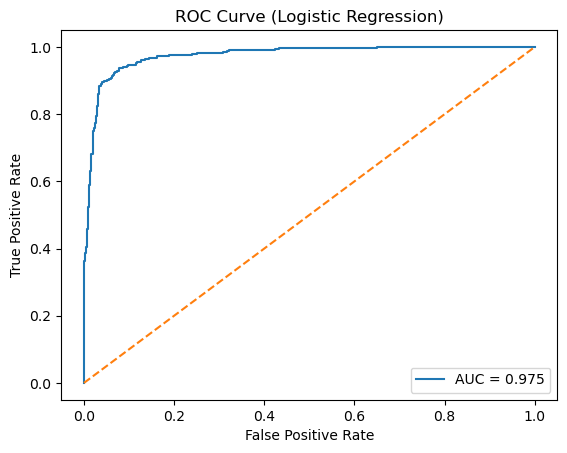

In [94]:

logreg = LogisticRegression(max_iter=5000)
logreg.fit(X_train, y_train)

pred_prob = logreg.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, pred_prob)
roc_auc = auc(fpr, tpr)

print("AUC:", roc_auc)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Logistic Regression)")
plt.legend()
plt.show()

Write code to plot a ROC curve without a package for logistic regression. Vary the prediction threshold $T \in \{0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1\}$, and compute false positive and true positive rates for each threshold. Plot a ROC curve for these points, and compare it with the ROC curve generated with the package in part (3). What are the differences and what changes can you make to get the two ROC curves to become more similar?

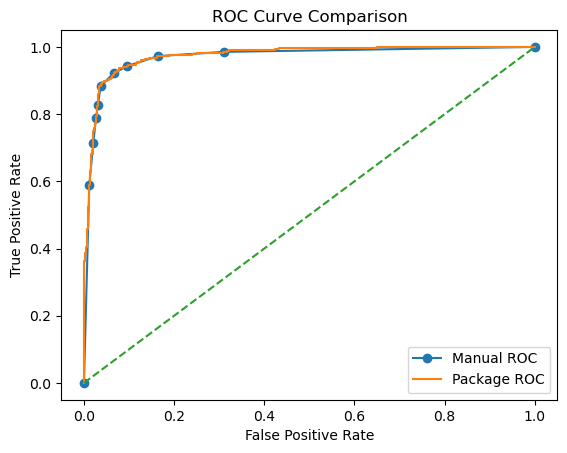

In [95]:
thresholds = np.arange(0,1.1,0.1)

fpr_list = []
tpr_list = []
pred_prob = logreg.predict_proba(X_test)[:,1]

for T in thresholds:
    preds = (pred_prob >= T).astype(int)
    
    TP = np.sum((preds == 1) & (y_test == 1))
    FP = np.sum((preds == 1) & (y_test == 0))
    TN = np.sum((preds == 0) & (y_test == 0))
    FN = np.sum((preds == 0) & (y_test == 1))
    
    TPR = TP / (TP + FN)
    FPR = FP / (FP + TN)
    
    tpr_list.append(TPR)
    fpr_list.append(FPR)

    
plt.plot(fpr_list, tpr_list, marker='o', label="Manual ROC")
plt.plot(fpr, tpr, label="Package ROC")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()